## Chemotaxis Gradient Random Walk

This walk will promote "running" and suppress tumbling if the concentration is getting stronger and the inverse if the cell is moving to a lesser concentration

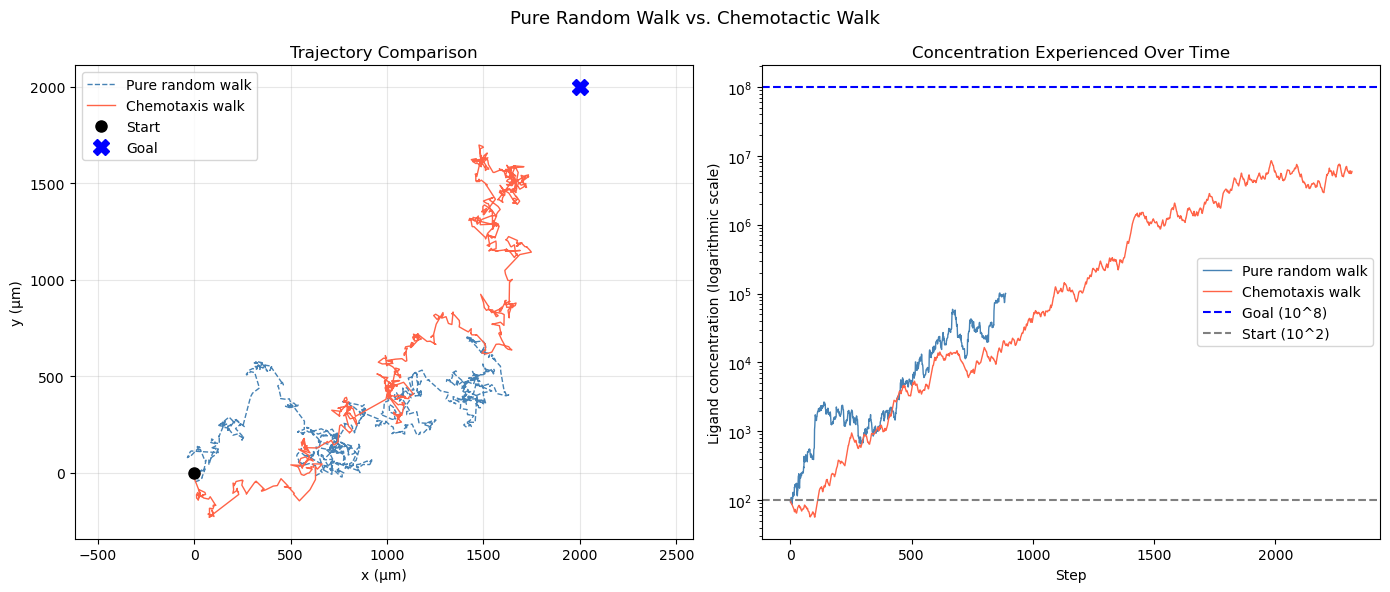

Pure random walk — final distance to goal: 1415.4 µm
Chemotaxis walk  — final distance to goal: 578.9 µm


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math

# --- Base Parameters ---
np.random.seed(371)
speed = 20             # Unit: micrometre/second
run_duration = 1.0     # Mean background run time (seconds)
tumble_duration = 0.1  # Mean tumble time (seconds)
total_duration = 1000  # Total simulation runtime (seconds)
response_time = 0.5    # How often the cell reassesses whether to tumble (seconds)
                       # ~0.5s matches observed E. coli response time to attractant

# --- Location & Concentration ---
start = [0.0, 0.0]
goal = [2000.0, 2000.0]   # Highest concentration point
start_exponent = 2
goal_exponent = 8
saturation_conc = 10 ** 8  # Receptors saturate at this concentration

# --- Distance & Concentration Functions ---

def distance(a, b):
    """Euclidean distance between two [x, y] points."""
    return math.sqrt((a[0] - b[0])**2 + (a[1] - b[1])**2)

def calculate_concentration(pos, origin_to_center):
    """
    Returns ligand concentration at pos using an exponential gradient.
    Concentration is 10^2 at origin and 10^8 at goal.
    """
    dist = distance(pos, goal)
    exponent = (1 - dist / origin_to_center) * (goal_exponent - start_exponent) + start_exponent
    return 10 ** exponent

# --- Run Duration Function (KEY addition from tutorial) ---

def get_run_duration(curr_conc, past_conc, run_time_expected):
 
    # Cap concentration at saturation — receptors can't detect above this
    curr_conc = min(curr_conc, saturation_conc)
    past_conc = min(past_conc, saturation_conc)

    # Proportional change in concentration
    delta_L = (curr_conc - past_conc) / past_conc

    # Adjust mean run time based on concentration change
    adjusted_mean = run_time_expected * (1 + 10 * delta_L)

    # Clamp: must be positive, and can't increase run time more than 4x
    adjusted_mean = max(0.000001, adjusted_mean)
    adjusted_mean = min(4 * run_time_expected, adjusted_mean)

    # Sample run duration from exponential distribution
    curr_run_time = np.random.exponential(adjusted_mean)
    return curr_run_time

# --- Core Simulation Function ---

def simulate_one_cell(duration, run_time_expected, chemotaxis=False, seed=None):
    """
    Simulates a single E. coli cell doing a random walk.

    For the chemotactic walk, every response_time seconds the cell reassesses
    whether to tumble based on the relative change in attractant concentration:
        - If sampled run time < response_time → run for that time, then tumble
        - If sampled run time >= response_time → run for response_time, then reassess

    Parameters:
        duration         : int   - how many seconds to run the simulation
        run_time_expected: float - mean background run duration (seconds)
        chemotaxis       : bool  - if True, use gradient-biased run duration
        seed             : int   - optional random seed for reproducibility

    Returns:
        path                : list of [x, y] positions at each recorded step
        concentration_path  : list of concentrations at each recorded position
    """
    if seed is not None:
        np.random.seed(seed)

    origin_to_center = distance(start, goal)
    position = np.array(start, dtype=float)

    # Initialize direction randomly
    angle = np.random.uniform(0, 2 * math.pi)
    proj_h = math.cos(angle)
    proj_v = math.sin(angle)

    path = [position.copy()]
    past_conc = calculate_concentration(position, origin_to_center)
    concentration_path = [past_conc]

    t = 0
    while t < duration:

        curr_conc = calculate_concentration(position, origin_to_center)

        if chemotaxis:
            # --- CHEMOTACTIC WALK ---
            # Get run duration based on relative concentration change
            curr_run_time = get_run_duration(curr_conc, past_conc, run_time_expected)

            if curr_run_time < response_time:
                # Run for curr_run_time seconds, then tumble
                position = position + np.array([proj_h, proj_v]) * speed * curr_run_time
                # Tumble: pick a new random direction
                angle = np.random.uniform(0, 2 * math.pi)
                proj_h = math.cos(angle)
                proj_v = math.sin(angle)
                tumble_time = np.random.exponential(tumble_duration)
                t += curr_run_time + tumble_time
            else:
                # Run for one response_time step without tumbling, then reassess
                position = position + np.array([proj_h, proj_v]) * speed * response_time
                t += response_time

        else:
            # --- PURE RANDOM WALK ---
            # Run time sampled from exponential with fixed mean
            curr_run_time = np.random.exponential(run_time_expected)
            position = position + np.array([proj_h, proj_v]) * speed * curr_run_time
            # Tumble: pick a new random direction
            angle = np.random.uniform(0, 2 * math.pi)
            proj_h = math.cos(angle)
            proj_v = math.sin(angle)
            tumble_time = np.random.exponential(tumble_duration)
            t += curr_run_time + tumble_time

        # Record position and concentration
        path.append(position.copy())
        past_conc = curr_conc
        concentration_path.append(calculate_concentration(position, origin_to_center))

    return path, concentration_path


# --- Run Both Models ---
path_random, conc_random = simulate_one_cell(duration=1000, run_time_expected=1.0,
                                              chemotaxis=False, seed=371)
path_chemo,  conc_chemo  = simulate_one_cell(duration=1000, run_time_expected=1.0,
                                              chemotaxis=True,  seed=371)

path_random = np.array(path_random)
path_chemo  = np.array(path_chemo)

# --- Plot ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: trajectories
ax1.plot(path_random[:, 0], path_random[:, 1], lw=1.0, alpha=1.0,
         color='steelblue',linestyle='--', label='Pure random walk')
ax1.plot(path_chemo[:, 0],  path_chemo[:, 1],  lw=1.0, alpha=1.0,
         color='tomato',   label='Chemotaxis walk')
ax1.plot(*start, 'ko', markersize=8, label='Start')
ax1.plot(*goal,  'bX', markersize=12, label='Goal')
ax1.set_xlabel("x (µm)")
ax1.set_ylabel("y (µm)")
ax1.set_title("Trajectory Comparison")
ax1.legend()
ax1.axis('equal')
ax1.grid(alpha=0.3)

# Right: concentration over time
ax2.plot(conc_random, lw=1, color='steelblue', label='Pure random walk')
ax2.plot(conc_chemo,  lw=1, color='tomato',    label='Chemotaxis walk')
ax2.set_yscale('log')
ax2.axhline(y=10**8, color='blue', linestyle='--', label='Goal (10^8)')
ax2.axhline(y=10**2, color='gray', linestyle='--', label='Start (10^2)')
ax2.set_xlabel("Step")
ax2.set_ylabel("Ligand concentration (logarithmic scale)")
ax2.set_title("Concentration Experienced Over Time")
ax2.legend()


plt.suptitle("Pure Random Walk vs. Chemotactic Walk", fontsize=13)
plt.tight_layout()
plt.savefig("gradient_walk.png", dpi=400, bbox_inches="tight")
plt.show()

# --- Summary ---
dist_random = distance(path_random[-1], goal)
dist_chemo  = distance(path_chemo[-1],  goal)
print(f"Pure random walk — final distance to goal: {dist_random:.1f} µm")
print(f"Chemotaxis walk  — final distance to goal: {dist_chemo:.1f} µm")


α =  1 | final distance to goal: 2172.4 µm
α =  3 | final distance to goal: 1813.8 µm
α =  5 | final distance to goal: 1136.1 µm
α = 10 | final distance to goal: 578.9 µm
α = 12 | final distance to goal: 35.7 µm


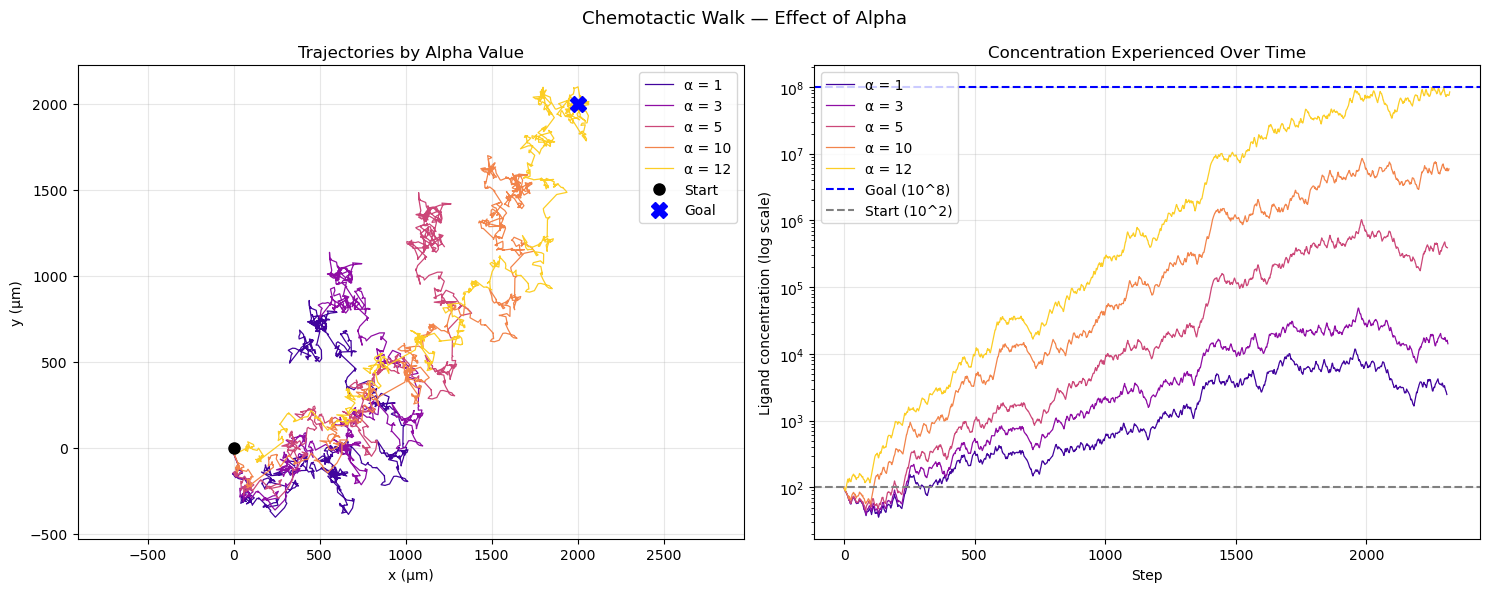

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import math

# --- Base Parameters ---
speed = 20
run_duration = 1.0
tumble_duration = 0.1
total_duration = 1000
response_time = 0.5

start = [0.0, 0.0]
goal = [2000.0, 2000.0]
start_exponent = 2
goal_exponent = 8
saturation_conc = 10 ** 8

# --- Helper Functions (unchanged) ---
def distance(a, b):
    return math.sqrt((a[0] - b[0])**2 + (a[1] - b[1])**2)

def calculate_concentration(pos, origin_to_center):
    dist = distance(pos, goal)
    exponent = (1 - dist / origin_to_center) * (goal_exponent - start_exponent) + start_exponent
    return 10 ** exponent

def get_run_duration(curr_conc, past_conc, run_time_expected, alpha):
    curr_conc = min(curr_conc, saturation_conc)
    past_conc = min(past_conc, saturation_conc)
    delta_L = (curr_conc - past_conc) / past_conc
    adjusted_mean = run_time_expected * (1 + alpha * delta_L)
    adjusted_mean = max(0.000001, adjusted_mean)
    adjusted_mean = min(4 * run_time_expected, adjusted_mean)
    return np.random.exponential(adjusted_mean)

# --- Simulation: alpha added as parameter ---
def simulate_one_cell(duration, run_time_expected, chemotaxis=False, alpha=10, seed=None):
    if seed is not None:
        np.random.seed(seed)

    origin_to_center = distance(start, goal)
    position = np.array(start, dtype=float)
    angle = np.random.uniform(0, 2 * math.pi)
    proj_h = math.cos(angle)
    proj_v = math.sin(angle)

    path = [position.copy()]
    past_conc = calculate_concentration(position, origin_to_center)
    concentration_path = [past_conc]

    t = 0
    while t < duration:
        curr_conc = calculate_concentration(position, origin_to_center)

        if chemotaxis:
            curr_run_time = get_run_duration(curr_conc, past_conc, run_time_expected, alpha)  # alpha passed here
            if curr_run_time < response_time:
                position = position + np.array([proj_h, proj_v]) * speed * curr_run_time
                angle = np.random.uniform(0, 2 * math.pi)
                proj_h = math.cos(angle)
                proj_v = math.sin(angle)
                tumble_time = np.random.exponential(tumble_duration)
                t += curr_run_time + tumble_time
            else:
                position = position + np.array([proj_h, proj_v]) * speed * response_time
                t += response_time
        else:
            curr_run_time = np.random.exponential(run_time_expected)
            position = position + np.array([proj_h, proj_v]) * speed * curr_run_time
            angle = np.random.uniform(0, 2 * math.pi)
            proj_h = math.cos(angle)
            proj_v = math.sin(angle)
            tumble_time = np.random.exponential(tumble_duration)
            t += curr_run_time + tumble_time

        path.append(position.copy())
        past_conc = curr_conc
        concentration_path.append(calculate_concentration(position, origin_to_center))

    return path, concentration_path


# --- Run over alpha values only ---
alpha_values = [1, 3, 5, 10, 12]
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(alpha_values)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

for color, alpha in zip(colors, alpha_values):
    path, conc = simulate_one_cell(duration=1000, run_time_expected=1.0,
                                   chemotaxis=True, alpha=alpha, seed=371)
    path = np.array(path)

    ax1.plot(path[:, 0], path[:, 1], lw=0.9, alpha=1, color=color, label=f'α = {alpha}')
    ax2.plot(conc, lw=0.9, alpha=1, color=color, label=f'α = {alpha}')

    print(f"α = {alpha:>2} | final distance to goal: {distance(path[-1], goal):.1f} µm")

# Start / goal markers
ax1.plot(*start, 'ko', markersize=8, label='Start')
ax1.plot(*goal,  'bX', markersize=12, label='Goal')
ax1.set_xlabel("x (µm)")
ax1.set_ylabel("y (µm)")
ax1.set_title("Trajectories by Alpha Value")
ax1.legend(fontsize=10)
ax1.axis('equal')
ax1.grid(alpha=0.3)

ax2.axhline(y=10**8, color='blue', linestyle='--', label='Goal (10^8)')
ax2.axhline(y=10**2, color='gray', linestyle='--', label='Start (10^2)')
ax2.set_yscale('log')
ax2.set_xlabel("Step")
ax2.set_ylabel("Ligand concentration (log scale)")
ax2.set_title("Concentration Experienced Over Time")
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.suptitle("Chemotactic Walk — Effect of Alpha", fontsize=13)
plt.tight_layout()
plt.savefig("gradient_walk_alpha.png", dpi=400, bbox_inches="tight")
plt.show()

Seed 371 | Random: 1415.4 µm | Chemo: 578.9 µm
Seed 42 | Random: 2589.8 µm | Chemo: 51.2 µm
Seed 99 | Random: 3122.6 µm | Chemo: 905.7 µm
Seed 7 | Random: 2146.9 µm | Chemo: 1116.3 µm
Seed 256 | Random: 3544.2 µm | Chemo: 81.1 µm


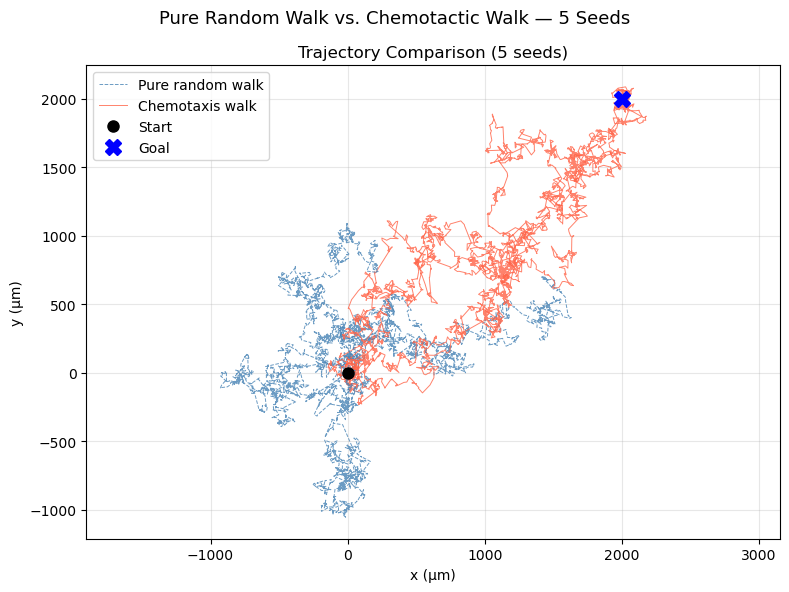

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import math

# --- Base Parameters ---
speed = 20
run_duration = 1.0
tumble_duration = 0.1
total_duration = 1000
response_time = 0.5

start = [0.0, 0.0]
goal = [2000.0, 2000.0]
start_exponent = 2
goal_exponent = 8
saturation_conc = 10 ** 8

# --- Same helper functions as before (unchanged) ---
def distance(a, b):
    return math.sqrt((a[0] - b[0])**2 + (a[1] - b[1])**2)

def calculate_concentration(pos, origin_to_center):
    dist = distance(pos, goal)
    exponent = (1 - dist / origin_to_center) * (goal_exponent - start_exponent) + start_exponent
    return 10 ** exponent

def get_run_duration(curr_conc, past_conc, run_time_expected):
    curr_conc = min(curr_conc, saturation_conc)
    past_conc = min(past_conc, saturation_conc)
    delta_L = (curr_conc - past_conc) / past_conc
    adjusted_mean = run_time_expected * (1 + 10 * delta_L)
    adjusted_mean = max(0.000001, adjusted_mean)
    adjusted_mean = min(4 * run_time_expected, adjusted_mean)
    return np.random.exponential(adjusted_mean)

def simulate_one_cell(duration, run_time_expected, chemotaxis=False, seed=None):
    if seed is not None:
        np.random.seed(seed)
    origin_to_center = distance(start, goal)
    position = np.array(start, dtype=float)
    angle = np.random.uniform(0, 2 * math.pi)
    proj_h = math.cos(angle)
    proj_v = math.sin(angle)
    path = [position.copy()]
    past_conc = calculate_concentration(position, origin_to_center)
    concentration_path = [past_conc]
    t = 0
    while t < duration:
        curr_conc = calculate_concentration(position, origin_to_center)
        if chemotaxis:
            curr_run_time = get_run_duration(curr_conc, past_conc, run_time_expected)
            if curr_run_time < response_time:
                position = position + np.array([proj_h, proj_v]) * speed * curr_run_time
                angle = np.random.uniform(0, 2 * math.pi)
                proj_h = math.cos(angle)
                proj_v = math.sin(angle)
                tumble_time = np.random.exponential(tumble_duration)
                t += curr_run_time + tumble_time
            else:
                position = position + np.array([proj_h, proj_v]) * speed * response_time
                t += response_time
        else:
            curr_run_time = np.random.exponential(run_time_expected)
            position = position + np.array([proj_h, proj_v]) * speed * curr_run_time
            angle = np.random.uniform(0, 2 * math.pi)
            proj_h = math.cos(angle)
            proj_v = math.sin(angle)
            tumble_time = np.random.exponential(tumble_duration)
            t += curr_run_time + tumble_time
        path.append(position.copy())
        past_conc = curr_conc
        concentration_path.append(calculate_concentration(position, origin_to_center))
    return path, concentration_path


# --- NEW: Run over multiple seeds ---
seeds = [371, 42, 99, 7, 256]

fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))

for i, seed in enumerate(seeds):
    # Label only the first run of each type to avoid legend clutter
    label_random = 'Pure random walk' if i == 0 else '_nolegend_'
    label_chemo  = 'Chemotaxis walk'  if i == 0 else '_nolegend_'

    path_random, conc_random = simulate_one_cell(1000, 1.0, chemotaxis=False, seed=seed)
    path_chemo,  conc_chemo  = simulate_one_cell(1000, 1.0, chemotaxis=True,  seed=seed)

    path_random = np.array(path_random)
    path_chemo  = np.array(path_chemo)

    # Trajectories
    ax1.plot(path_random[:, 0], path_random[:, 1],
             lw=0.7, alpha=0.8, color='steelblue', linestyle='--', label=label_random)
    ax1.plot(path_chemo[:, 0],  path_chemo[:, 1],
             lw=0.7, alpha=0.8, color='tomato', label=label_chemo)

    print(f"Seed {seed} | Random: {distance(path_random[-1], goal):.1f} µm | "
          f"Chemo: {distance(path_chemo[-1], goal):.1f} µm")

# Start/goal markers (drawn once, on top)
ax1.plot(*start, 'ko', markersize=8, label='Start')
ax1.plot(*goal,  'bX', markersize=12, label='Goal')
ax1.set_xlabel("x (µm)")
ax1.set_ylabel("y (µm)")
ax1.set_title("Trajectory Comparison (5 seeds)")
ax1.legend()
ax1.axis('equal')
ax1.grid(alpha=0.3)

plt.suptitle("Pure Random Walk vs. Chemotactic Walk — 5 Seeds", fontsize=13)
plt.tight_layout()
plt.savefig("gradient_walk_multiseed.png", dpi=600, bbox_inches="tight")
plt.show()